# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks.

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

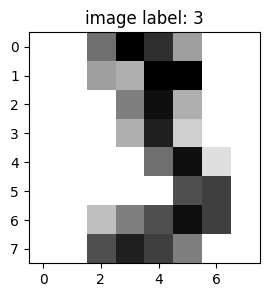

In [3]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [4]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [5]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [6]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [7]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [8]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [9]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [10]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [11]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [12]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [13]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [14]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [15]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [16]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model.
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [17]:
import numpy as np

def softmax(X):
    """Softmax function to normalize the output into probabilities."""
    exp_X = np.exp(X - np.max(X, axis=1, keepdims=True))  # Numerical stability
    return exp_X / np.sum(exp_X, axis=1, keepdims=True)

def one_hot(output_size, y):
    """One-hot encoding for the target labels."""
    one_hot_encoded = np.zeros((len(y), output_size))
    one_hot_encoded[np.arange(len(y)), y] = 1
    return one_hot_encoded

class LogisticRegression:
    def __init__(self, input_size, output_size):
        # Initialize the weights and biases with random numbers
        self.W = np.random.uniform(size=(input_size, output_size), high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size, high=0.1, low=-0.1)

        # Store the input size and output size
        self.output_size = output_size
        self.input_size = input_size

    def forward(self, X):
        """Compute the forward pass: linear combination of input and weights followed by softmax."""
        Z = np.dot(X, self.W) + self.b  # Linear combination
        return softmax(Z)  # Apply softmax to get probabilities

    def predict(self, X):
        """Return the most probable class for each sample in X."""
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def loss(self, X, y):
        """Compute the negative log likelihood loss over the data."""
        Y_pred = self.forward(X)
        y_onehot = one_hot(self.output_size, y.astype(int))  # One-hot encode the labels
        # Cross-entropy loss
        return -np.sum(y_onehot * np.log(Y_pred + 1e-8)) / X.shape[0]

    def grad_loss(self, X, y_true, y_pred):
        """Compute the gradient of the loss with respect to W and b for a single sample (X, y_true)."""
        # Gradient with respect to output layer
        grad_W = np.dot(X.T, (y_pred - y_true))
        grad_b = np.sum(y_pred - y_true, axis=0)
        return grad_W, grad_b

# Create a logistic regression model
model = LogisticRegression(input_size=64, output_size=10)

# Test the implementation
try:
    # Ensure forward pass returns the correct shape
    assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
    # Ensure loss is computed properly and is greater than 0
    assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")


In [18]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

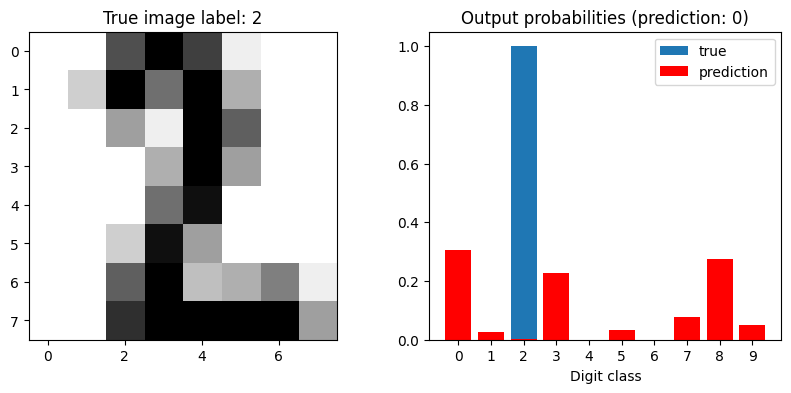

In [19]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    # Display the true image
    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx])

    # Convert the true label to a one-hot vector
    y_true = np.array([y_test[sample_idx]])  # Ensure it's an array for one-hot encoding
    y_true_one_hot = one_hot(len(classes), y_true)  # One-hot encoding for the true label
    ax1.bar(classes, y_true_one_hot[0], label='true')  # y_true_one_hot[0] because it's a 2D array

    # Get the model's predictions (probabilities)
    y_pred = model.forward(X_test[sample_idx:sample_idx+1])  # Shape (1, 10)
    ax1.bar(classes, y_pred[0], label='prediction', color="red")  # y_pred[0] is the 1D array of predicted probabilities
    ax1.set_xticks(classes)

    # Make a prediction for the class label
    prediction = model.predict(X_test[sample_idx:sample_idx+1])  # This will be a scalar value
    ax1.set_title('Output probabilities (prediction: %d)' % prediction[0])  # prediction[0] to get the scalar value
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)


Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [20]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.01

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps
    if i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 0: nan
Average NLL over the last 100 samples at step 100: 3
Average NLL over the last 100 samples at step 200: 2
Average NLL over the last 100 samples at step 300: 3
Average NLL over the last 100 samples at step 400: 3
Average NLL over the last 100 samples at step 500: 1
Average NLL over the last 100 samples at step 600: 1
Average NLL over the last 100 samples at step 700: 2
Average NLL over the last 100 samples at step 800: 1
Average NLL over the last 100 samples at step 900: 1
Average NLL over the last 100 samples at step 1000: 2
Average NLL over the last 100 samples at step 1100: 1
Average NLL over the last 100 samples at step 1200: 1
Average NLL over the last 100 samples at step 1300: 1
Average NLL over the last 100 samples at step 1400: 1
Average NLL over the last 100 samples at step 1500: 1


<ipython-input-17-15f4f519e139>:41: RuntimeWarning: invalid value encountered in scalar divide
  return -np.sum(y_onehot * np.log(Y_pred + 1e-8)) / X.shape[0]


Evaluate the trained model on the first example:

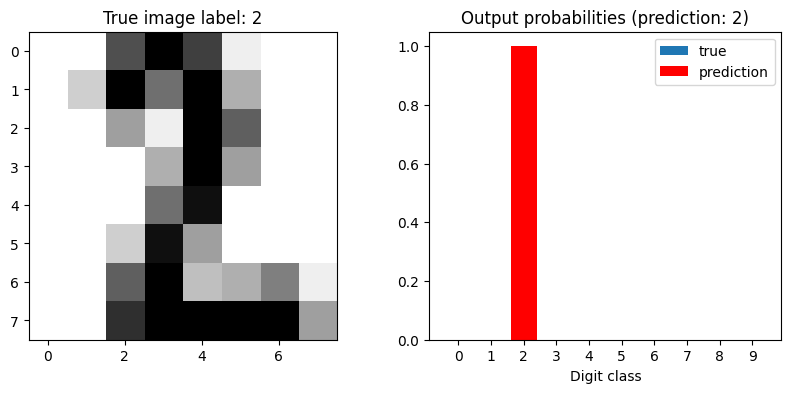

In [21]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

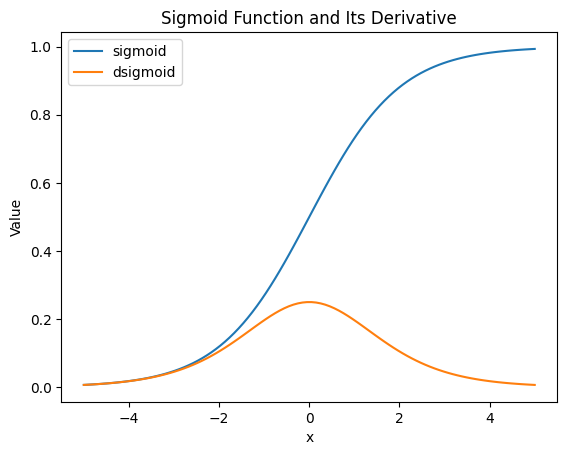

In [22]:
def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500)  # This ensures that np.exp(X) doesn't overflow
    return 1 / (1 + np.exp(-X))  # Sigmoid formula

def dsigmoid(X):
    # The derivative of the sigmoid is sigmoid(X) * (1 - sigmoid(X))
    sigmoid_X = sigmoid(X)
    return sigmoid_X * (1 - sigmoid_X)

# Generate values for X
x = np.linspace(-5, 5, 100)

# Plot the sigmoid and its derivative
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best')
plt.title('Sigmoid Function and Its Derivative')
plt.xlabel('x')
plt.ylabel('Value')
plt.show()

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [23]:
class NeuralNet:
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights
        Z_h = np.dot(X, self.W_h) + self.b_h
        # Apply the sigmoid activation function
        return sigmoid(Z_h)

    def forward_output(self, H):
        # Compute the linear combination of the hidden layer activation and weights
        Z_o = np.dot(H, self.W_o) + self.b_o
        # Apply the sigmoid activation function
        return sigmoid(Z_o)

    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)
        return Y

    def loss(self, X, y):
        # Cross-entropy loss for multi-class classification
        y = y.astype(int)  # Ensure y is an integer type
        y_onehot = one_hot(self.output_size, y)
        y_pred = self.forward(X)
        return -np.sum(y_onehot * np.log(y_pred + 1e-8)) / X.shape[0]

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = np.dot(self.Z_h.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D (add batch dimension)
        x = x[np.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)

        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)

# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    assert(nn.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

Once the code is written, we can test our model on a single sample:

In [24]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [25]:
model.loss(X_train, y_train)

0.7067209524256247

In [26]:
model.accuracy(X_train, y_train)

0.10019646365422397

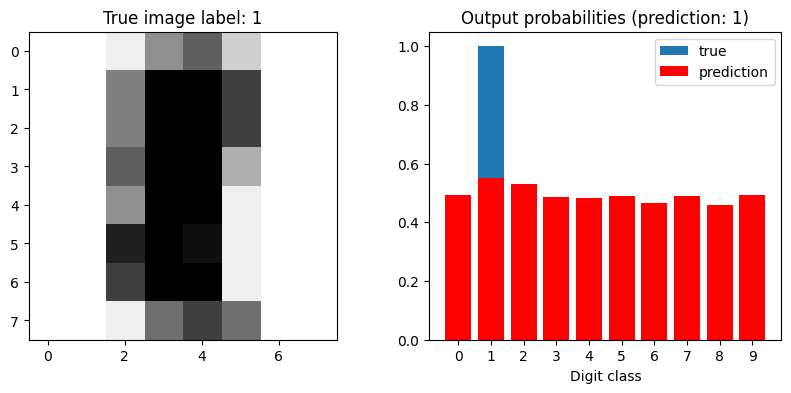

In [27]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [29]:
import numpy as np

# Sigmoid and derivative functions
def sigmoid(X):
    return 1 / (1 + np.exp(-X))

def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))

# One-hot encoding function
def one_hot(output_size, y):
    """One-hot encoding for the target labels."""
    y = np.array(y, dtype=int)
    if len(y.shape) == 0:  # If y is a scalar, make it a 1D array
        y = np.array([y])

    one_hot_encoded = np.zeros((len(y), output_size))
    one_hot_encoded[np.arange(len(y)), y] = 1
    return one_hot_encoded

class NeuralNet:
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size), high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size, high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size), high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size, high=0.1, low=-0.1)

        # Store the input size, hidden size, and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights
        self.Z_h = np.dot(X, self.W_h) + self.b_h
        # Apply the sigmoid activation function
        return sigmoid(self.Z_h)

    def forward_output(self, H):
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = np.dot(H, self.W_o) + self.b_o
        # Apply the sigmoid activation function
        return sigmoid(self.Z_o)

    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)
        return Y

    def loss(self, X, y):
        # Cross-entropy loss for multi-class classification
        y = y.astype(int)  # Ensure y is an integer type
        y_onehot = one_hot(self.output_size, y)
        y_pred = self.forward(X)
        return -np.sum(y_onehot * np.log(y_pred + 1e-8)) / X.shape[0]

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = np.dot(self.Z_h.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, X, y, learning_rate):
        # Ensure X is 2D
        X = X[np.newaxis, :] if len(X.shape) == 1 else X

        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(X, y)
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = self.predict(X)
        return np.mean(y_preds == y)

# Example of random data (replace this with actual data)
X_train = np.random.rand(100, 64)  # 100 samples, 64 features each
y_train = np.random.randint(0, 10, 100)  # 100 labels from 0 to 9
X_test = np.random.rand(20, 64)  # 20 test samples
y_test = np.random.randint(0, 10, 20)  # 20 test labels

# Initialize the model
model = NeuralNet(input_size=64, hidden_size=32, output_size=10)

# Initialize empty lists to store losses and accuracies
losses, accuracies, accuracies_test = [], [], []

# Calculate the initial loss and accuracy on both the train and test sets
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

# Print initial results
print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

# Training loop for 15 epochs
for epoch in range(15):
    # Loop through each sample in the training set
    for i in range(X_train.shape[0]):  # Loop over each sample in X_train
        x = X_train[i]  # Get the sample
        y = y_train[i]  # Get the label

        # Train the model on the single sample
        model.train(x, y, 0.001)

    # After each epoch, compute the loss and accuracy on both the train and test sets
    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))

    # Print the results for the current epoch
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))


Random init: train loss: 0.66843, train acc: 0.070, test acc: 0.050
Epoch #1, train loss: 0.70666, train acc: 0.100, test acc: 0.050
Epoch #2, train loss: 0.74749, train acc: 0.100, test acc: 0.050
Epoch #3, train loss: 0.79459, train acc: 0.120, test acc: 0.100
Epoch #4, train loss: 0.85127, train acc: 0.140, test acc: 0.200
Epoch #5, train loss: 0.91999, train acc: 0.160, test acc: 0.250
Epoch #6, train loss: 1.00154, train acc: 0.160, test acc: 0.250
Epoch #7, train loss: 1.09441, train acc: 0.150, test acc: 0.250
Epoch #8, train loss: 1.19506, train acc: 0.150, test acc: 0.250
Epoch #9, train loss: 1.29883, train acc: 0.160, test acc: 0.250
Epoch #10, train loss: 1.40118, train acc: 0.150, test acc: 0.100
Epoch #11, train loss: 1.49853, train acc: 0.140, test acc: 0.050
Epoch #12, train loss: 1.58857, train acc: 0.150, test acc: 0.050
Epoch #13, train loss: 1.67013, train acc: 0.160, test acc: 0.050
Epoch #14, train loss: 1.74291, train acc: 0.160, test acc: 0.050
Epoch #15, train 

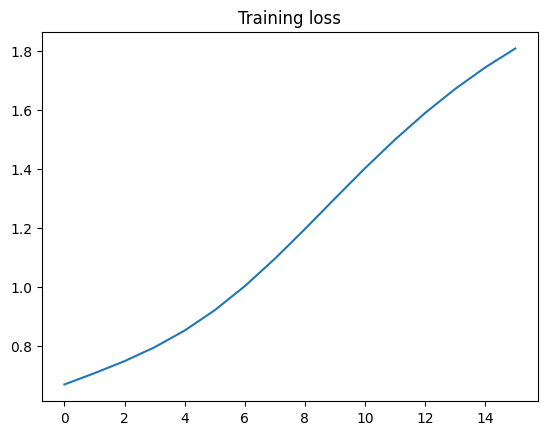

In [30]:
plt.plot(losses)
plt.title("Training loss");

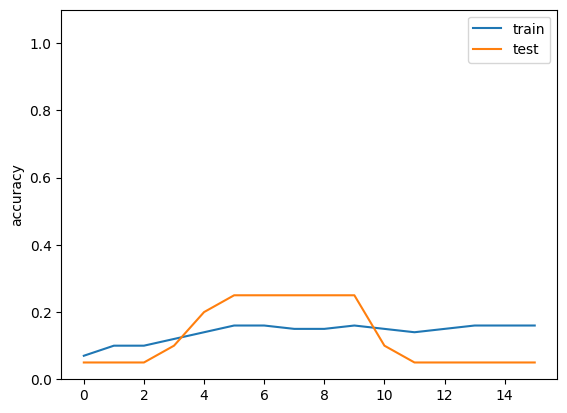

In [31]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

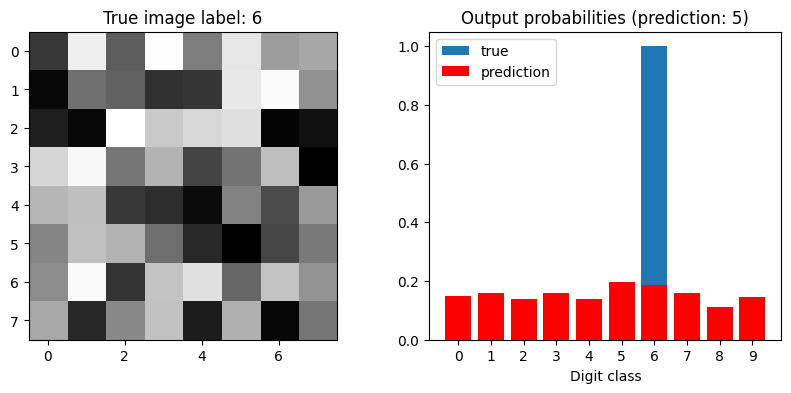

In [32]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

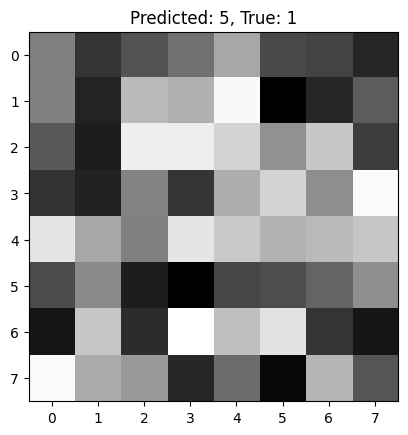

Prediction Error: 4 for sample 0, Predicted: 5, True: 1


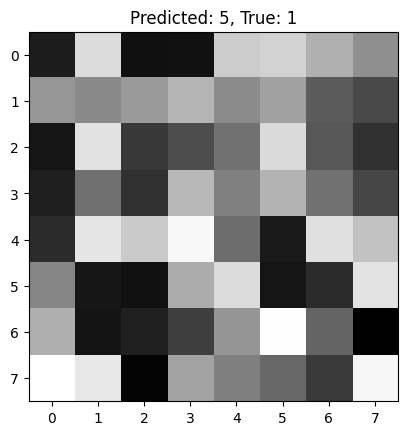

Prediction Error: 4 for sample 2, Predicted: 5, True: 1


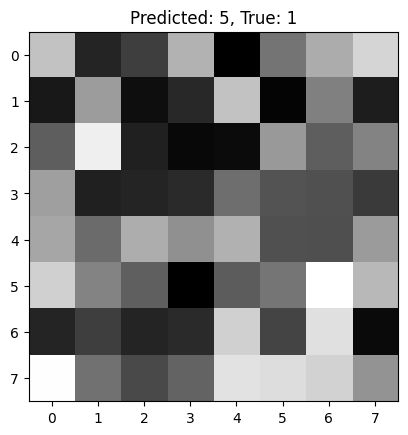

Prediction Error: 4 for sample 9, Predicted: 5, True: 1


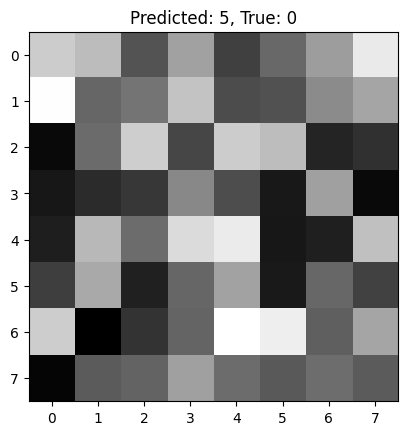

Prediction Error: 5 for sample 5, Predicted: 5, True: 0


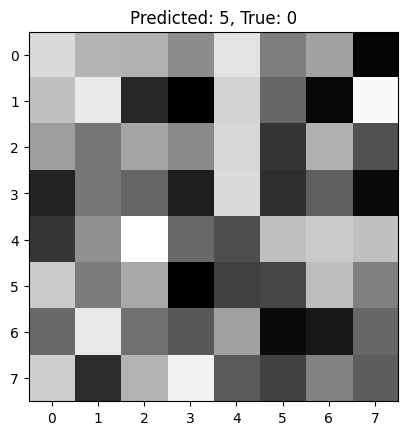

Prediction Error: 5 for sample 11, Predicted: 5, True: 0


In [34]:
# Your code here

import numpy as np
import matplotlib.pyplot as plt

# Assuming plot_prediction is defined, and we have X_test, y_test, model from previous code

# Step 1: Compute the predictions
y_preds = model.predict(X_test)

# Step 2: Calculate the absolute error for each sample
errors = np.abs(y_preds - y_test)

# Step 3: Find the indices of the worst prediction errors (e.g., top 5 worst errors)
top_errors_idx = np.argsort(errors)[-5:]  # Get indices of the top 5 worst prediction errors

# Step 4: Plot those samples with worst prediction errors
def plot_prediction(model, sample_idx):
    # Plot the image of the sample and show the predicted label
    sample = X_test[sample_idx]
    prediction = model.predict(sample)

    plt.imshow(sample.reshape(8, 8), cmap='gray')  # Assuming 64 features reshape to 8x8 for visualization
    plt.title(f"Predicted: {prediction}, True: {y_test[sample_idx]}")
    plt.show()

# Plot the top 5 worst predictions
for idx in top_errors_idx:
    plot_prediction(model, idx)
    print(f"Prediction Error: {errors[idx]} for sample {idx}, Predicted: {y_preds[idx]}, True: {y_test[idx]}")




### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(X):
    # Sigmoid activation function: used to introduce non-linearity
    return 1 / (1 + np.exp(-X))

def dsigmoid(X):
    # Derivative of the sigmoid function: used during backpropagation
    return sigmoid(X) * (1 - sigmoid(X))

def one_hot(output_size, y):
    # Converts the target labels into one-hot encoded format for multi-class classification
    y = np.array(y, dtype=int)
    if len(y.shape) == 0:  # If y is a scalar, make it a 1D array
        y = np.array([y])

    one_hot_encoded = np.zeros((len(y), output_size))  # Create an array of zeros with the shape (n_samples, output_size)
    one_hot_encoded[np.arange(len(y)), y] = 1  # Set the correct class indices to 1
    return one_hot_encoded

class NeuralNet:
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        # Initialize the neural network architecture with random weights and biases
        self.W_h1 = np.random.uniform(size=(input_size, hidden_size1), high=0.1, low=-0.1)  # Weights for hidden layer 1
        self.b_h1 = np.random.uniform(size=hidden_size1, high=0.1, low=-0.1)  # Biases for hidden layer 1

        self.W_h2 = np.random.uniform(size=(hidden_size1, hidden_size2), high=0.1, low=-0.1)  # Weights for hidden layer 2
        self.b_h2 = np.random.uniform(size=hidden_size2, high=0.1, low=-0.1)  # Biases for hidden layer 2

        self.W_o = np.random.uniform(size=(hidden_size2, output_size), high=0.1, low=-0.1)  # Weights for output layer
        self.b_o = np.random.uniform(size=output_size, high=0.1, low=-0.1)  # Biases for output layer

        self.input_size = input_size  # Store the input size
        self.hidden_size1 = hidden_size1  # Store the first hidden layer size
        self.hidden_size2 = hidden_size2  # Store the second hidden layer size
        self.output_size = output_size  # Store the output size

    def forward_hidden1(self, X):
        # Compute activations for the first hidden layer
        Z_h1 = np.dot(X, self.W_h1) + self.b_h1  # Linear transformation (W_h1 * X + b_h1)
        A_h1 = sigmoid(Z_h1)  # Apply the sigmoid activation function
        return Z_h1, A_h1

    def forward_hidden2(self, A_h1):
        # Compute activations for the second hidden layer
        Z_h2 = np.dot(A_h1, self.W_h2) + self.b_h2  # Linear transformation (W_h2 * A_h1 + b_h2)
        A_h2 = sigmoid(Z_h2)  # Apply the sigmoid activation function
        return Z_h2, A_h2

    def forward_output(self, A_h2):
        # Compute activations for the output layer
        Z_o = np.dot(A_h2, self.W_o) + self.b_o  # Linear transformation (W_o * A_h2 + b_o)
        A_o = sigmoid(Z_o)  # Apply the sigmoid activation function
        return Z_o, A_o

    def forward(self, X):
        # Perform the forward pass through all layers
        Z_h1, A_h1 = self.forward_hidden1(X)  # Get activations for the first hidden layer
        Z_h2, A_h2 = self.forward_hidden2(A_h1)  # Get activations for the second hidden layer
        Z_o, A_o = self.forward_output(A_h2)  # Get activations for the output layer

        # Store intermediate results for backpropagation
        self.Z_h1 = Z_h1
        self.A_h1 = A_h1
        self.Z_h2 = Z_h2
        self.A_h2 = A_h2
        self.Z_o = Z_o
        self.A_o = A_o

        return self.A_o  # Return the output layer activations

    def loss(self, X, y):
        # Compute the loss (cross-entropy) between predictions and true labels
        y_onehot = one_hot(self.output_size, y)  # Convert the true labels to one-hot encoding
        y_pred = self.forward(X)  # Get predictions from the model
        return -np.sum(y_onehot * np.log(y_pred + 1e-8)) / X.shape[0]  # Compute the cross-entropy loss

    def grad_loss(self, X, y_true):
        # Compute gradients for all weights and biases using backpropagation
        y_true = one_hot(self.output_size, y_true)  # One-hot encode the true labels
        y_pred = self.forward(X)  # Get predictions from the model

        # Compute error at the output layer (difference between predicted and true values)
        error_o = y_pred - y_true
        grad_W_o = np.dot(self.A_h2.T, error_o)  # Gradient of output layer weights (shape: hidden_size2, output_size)
        grad_b_o = np.sum(error_o, axis=0)  # Gradient of output layer biases (sum over all samples)

        # Compute error at the second hidden layer (propagate error backwards)
        error_h2 = np.dot(error_o, self.W_o.T) * dsigmoid(self.A_h2)  # Error at hidden layer 2
        grad_W_h2 = np.dot(self.A_h1.T, error_h2)  # Gradient of hidden layer 2 weights (shape: hidden_size1, hidden_size2)
        grad_b_h2 = np.sum(error_h2, axis=0)  # Gradient of hidden layer 2 biases

        # Compute error at the first hidden layer (propagate error backwards)
        error_h1 = np.dot(error_h2, self.W_h2.T) * dsigmoid(self.A_h1)  # Error at hidden layer 1
        grad_W_h1 = np.dot(X.T, error_h1)  # Gradient of hidden layer 1 weights (shape: input_size, hidden_size1)
        grad_b_h1 = np.sum(error_h1, axis=0)  # Gradient of hidden layer 1 biases

        # Return the gradients for all weights and biases
        return {"W_h1": grad_W_h1, "b_h1": grad_b_h1,
                "W_h2": grad_W_h2, "b_h2": grad_b_h2,
                "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, X, y, learning_rate):
        # Update weights and biases using the computed gradients
        grads = self.grad_loss(X, y)  # Get gradients for all layers

        # Update weights and biases for all layers using gradient descent
        self.W_h1 -= learning_rate * grads["W_h1"]
        self.b_h1 -= learning_rate * grads["b_h1"]
        self.W_h2 -= learning_rate * grads["W_h2"]
        self.b_h2 -= learning_rate * grads["b_h2"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

    def predict(self, X):
        # Predict the class by choosing the class with the highest output
        return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        # Compute the accuracy of the model
        y_preds = self.predict(X)  # Get predicted labels
        return np.mean(y_preds == y)  # Compute the accuracy by comparing predictions to true labels



# The above code creates a Neural Network class with two hidden layers and an output layer.
# The forward function computes the activations of the layers during the forward pass.
# The grad_loss function computes the gradients for backpropagation, and the train function updates the weights and biases using these gradients.
# Finally, the accuracy function computes how well the model's predictions match the true labels.
